---
# Denoising Diffusion Probabilistic Model 
---
In this exercise, we will implement a Denoising Diffusion Probabilistic Model (DDPM) and apply it to the AFHQ Cat dataset. 

Again, we highly recommend to use a GPU, as the training of the models can take a long time on CPU. 

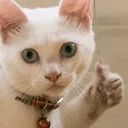


A diffusion model learns to denoise images by gradually removing noise from a noisy image. This allows us to generate new images by starting from pure noise and iteratively denoising it.

You do not need to read the papers to complete the exercise, but it is highly recommended to read them to gain a deeper understanding of the concepts and techniques involved in diffusion models.

Paper: [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239v2)

---
# Imports
---

Run the code cell below after you have set up everything correctly (either locally or in Colab).

In [1]:
import importlib

import torch

import data
import trainer
import utils
import visual
import tests
import models

---
## Load and Visualize the Data
---

We use the AFHQ Cat dataset. The task is easier to inspect visually than CIFAR-10 because all images come from one focused image distribution.

When `make_afhq_loaders` is called for the first time, the AFHQ dataset is downloaded and extracted. 

The cat images are resized to the requested `image_size` and cached in a folder such as `afhq_v2_32/`. On later runs, this cache is reused.

Before training a diffusion model, inspect a few validation images to verify that the data is loaded, normalized, resized, and batched correctly.

In [2]:
importlib.reload(data)

_, val_loader, _ = data.make_afhq_loaders(batch_size=16, num_workers=0, image_size=32)

x, _ = next(iter(val_loader))
visual._image_grid(x[:8], title="AFHQ validation images", cols=4)

Extracting AFHQ v2:   0%|          | 0/15811 [00:00<?, ?file/s]

Creating resized AFHQ cache 32x32:   0%|          | 0/15803 [00:00<?, ?it/s]

AFHQ raw dir: /data/afhq_v2
AFHQ resized dir: /data/afhq_v2_32
AFHQ image size: 32x32
AFHQ cat train: 5065
AFHQ cat val: 246
AFHQ cat test: 247


---
## DDPM Forward Process
---

In a Denoising Diffusion Probabilistic Model (DDPM), the **forward process** gradually destroys a clean image $x_0$ by adding Gaussian noise over $T$ steps.


At each step $t$, a small amount of noise is added according to a fixed variance schedule $\beta_t \in [\beta_{start}, \beta_{end}]$:

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}
\left(
x_t
\mid
\sqrt{1-\beta_t}\,x_{t-1},
\beta_t I
\right).
$$

A useful property of DDPMs is that we can create $x_t$ directly from $x_0$, without iterating through all intermediate steps. 

With $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ and $\alpha_t = 1 - \beta_t$, the marginal distribution of $x_t$ given $x_0$ is
$$
q(x_t \mid x_0)
=
\mathcal{N}
\left(
x_t
\mid
\sqrt{\bar{\alpha}_t}\,x_0,
(1-\bar{\alpha}_t)I
\right).
$$

Therefore, $x_t$ can be sampled as

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\varepsilon,
\qquad
\varepsilon \sim \mathcal{N}(0,I).
$$

This closed-form expression is used during training: for each clean image $x_0$, we sample a random time step $t$, add the corresponding amount of noise, and train the model to predict the added noise.

## **Task:**

Implement `precompute_ddpm_schedule`, and `q_sample` in `utils.py`.

**Hints:**
- The default values for `beta_start` and `beta_end` are $0.0001$ and $0.02$, respectively.
- For efficiency, `precompute_ddpm_schedule` should compute $\beta_t$, $\alpha_t$, $\bar{\alpha}_t$, $\sqrt{\bar{\alpha}_t}$, and $\sqrt{1 - \bar{\alpha}_t}$ for all $t$.
- You might find `torch.gather` useful.

In [3]:
importlib.reload(tests)
importlib.reload(utils)

tests.test_ddpm_schedule()
tests.test_q_sample()

✅ PASS: DDPM schedule seems to be correct.
✅ PASS: q_sample seems to be correct.


True

---
## Visualize the Forward Noising Process
---

After implementing `q_sample`, the following cell shows how a clean image is gradually destroyed by the forward process.

In [4]:
num_timesteps = 1000
schedule = utils.precompute_ddpm_schedule(num_timesteps, beta_start=1e-4, beta_end=2e-2)

x0 = x[:1]
noise = torch.randn_like(x0)
time_indices = torch.tensor([0, 100, 250, 500, 750, 999])

noised_images = []
for t_value in time_indices:
    t_batch = t_value.view(1)
    noised_images.append(utils.q_sample(x0, t_batch, noise, schedule["sqrt_alpha_bars"], schedule["sqrt_one_minus_alpha_bars"]))

noised_images = torch.cat(noised_images, dim=0).cpu()
visual._image_grid(noised_images, title="DDPM forward noising process", cols=6)

---
## DDPM Sampling
---

DDPM sampling starts from pure Gaussian noise and repeatedly applies a learned reverse denoising process.

During training, the model learns to predict the noise $\epsilon$ that was added to a clean image. During sampling, we use the predicted noise $\epsilon_\theta(x_t,t)$ to compute the mean of the reverse transition from $x_t$ to $x_{t-1}$.

For a model that predicts noise, one reverse step uses the mean

$$
\mu_\theta(x_t,t) = \frac{1}{\sqrt{\alpha_t}}
\left(
x_t -
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\epsilon_\theta(x_t,t)
\right).
$$

The reverse process is stochastic. For $t > 0$, we sample

$$
x_{t-1}
=
\mu_\theta(x_t,t)
+
\sigma_t z,
\qquad
z \sim \mathcal{N}(0,I).
$$

Here $\sigma_t^2$ is usually chosen as the posterior variance of the forward process,
$$
\sigma_t^2
= \tilde{\beta}_t
=
\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}
\beta_t.
$$

For $t=0$, no additional noise is added.

## **Task:**

Implement `ddpm_p_sample` and `ddpm_sample` in `utils.py`.

In [5]:
importlib.reload(tests)
importlib.reload(utils)

tests.test_ddpm_p_sample()
tests.test_ddpm_sample()

❌ FAIL: ddpm_p_sample gives incorrect values for an intermediate reverse step. Max error: 1.06e-02
✅ PASS: ddpm_sample seems to be correct.


True

---
## DDPM Training
---

The DDPM network predicts the noise that was added to $x_0$:
$$
\epsilon_\theta(x_t,t) \approx \epsilon.
$$

The training objective is the mean squared error
$$
\mathcal{L}_{DDPM} = \mathbb{E}_{x_0,t,\epsilon}\left[\lVert \epsilon - \epsilon_\theta(x_t,t) \rVert_2^2\right].
$$

Now we need to create the data loaders, initialize the U-Net, precompute the DDPM noise schedule, train the model for the requested number of epochs, and evaluate it on the validation set.

## **Task:**

Implement `train_ddpm` in `trainer.py`.

**Hints:**
- Use `AdamW` as the optimizer.
- Generate and display some samples every few epochs. This helps monitor whether the reverse diffusion process gradually produces meaningful images instead of pure noise. For that you can use `visual._image_grid`.

In [8]:
importlib.reload(trainer)
importlib.reload(data)
importlib.reload(models)


lr = 2e-4
betas=(0.9, 0.999)
weight_decay = 1e-4

num_timesteps = 1000
base_channels = 64
time_dim = 256
groups = 8

batch_size = 64
epochs = 100
image_size = 32
num_workers = 2


device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built() else "cpu")
print(f"Using device: {device}")

model, history = trainer.train_ddpm(
    num_timesteps=num_timesteps,
    base_channels=base_channels,
    time_dim=time_dim,
    groups=groups,
    batch_size=batch_size,
    lr=lr,
    betas=betas,
    weight_decay=weight_decay,
    epochs=epochs,
    device=device,
    num_workers=num_workers,
    image_size=image_size
)

visual.show_training_stats(history, title="DDPM Training").show()

Using device: cuda:0
AFHQ raw dir: /data/afhq_v2
AFHQ resized dir: /data/afhq_v2_32
AFHQ image size: 32x32
AFHQ cat train: 5065
AFHQ cat val: 246
AFHQ cat test: 247


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]